# SECTION 1: RESLSTM MODEL TRAINING

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Reshape, LSTM, Dense, Dropout, BatchNormalization, ReLU, Add
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, Adamax
from tensorflow.keras import backend as K
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ModelCheckpoint

# ========== SETUP ==========
SAMPLE_RATE = 22050
BATCH_SIZE = 64
NUM_CLASSES = 5

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


# === Custom Attention Layer ===
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super().build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

# === ResLSTM WITH ATTENTION ===
def residual_block(x, filters, stride):
    shortcut = Conv2D(filters, kernel_size=(1, 1), strides=stride, padding='same')(x)
    shortcut = BatchNormalization()(shortcut)

    x = Conv2D(filters, kernel_size=(3, 3), strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(filters, kernel_size=(3, 3), padding='same')(x)
    x = BatchNormalization()(x)

    x = Add()([shortcut, x])
    x = ReLU()(x)
    return x

def build_reslstm_attention(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv2D(16, kernel_size=(5, 5), strides=1, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    for filters, stride in zip([32, 64, 64], [2, 1, 1]):
        x = residual_block(x, filters, stride)
        x = Dropout(0.3)(x)

    x = Reshape((x.shape[1], x.shape[2]*x.shape[3]))(x)
    x = LSTM(32, return_sequences=True)(x)
    x = Dropout(0.3)(x)
    x = AttentionLayer()(x)

    output = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, output)

# === Universal Run Function ResLSTM ===
def run_attention_model(model_type="reslstm", optimizer_name="Adam", lr=0.001, epochs=60, split_ratio=(0.8, 0.1, 0.1), batch_size=32):
    X = np.load("X_balanced.npy")
    y = np.load("y_balanced.npy")
    X = X / np.max(X)
    X = X[..., np.newaxis]

    class_names = ["belly pain", "burping", "discomfort", "hungry", "tired"]
    num_classes = len(np.unique(y))
    y_cat = to_categorical(y, num_classes)

    X_temp, X_test, y_temp, y_test = train_test_split(X, y_cat, test_size=split_ratio[2], stratify=y, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=split_ratio[1]/(split_ratio[0]+split_ratio[1]), stratify=y_temp.argmax(1), random_state=42)

    if model_type == "reslstm":
        model = build_reslstm_attention(X_train.shape[1:], num_classes)
    else:
        model = build_cnn_lstm_attention(X_train.shape[1:], num_classes)

    if optimizer_name == "SGD":
        optimizer = SGD(learning_rate=lr)
    elif optimizer_name == "Adamax":
        optimizer = Adamax(learning_rate=lr)
    elif optimizer_name == "RMSprop":
        optimizer = RMSprop(learning_rate=lr)
    else:
        optimizer = Adam(learning_rate=lr)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    checkpoint = ModelCheckpoint(
        filepath='best_model_ResLSTM.h5' if model_type == 'reslstm' else 'best_model_CNNLSTM.h5',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )

    callbacks = [early_stop, checkpoint]

    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=epochs, batch_size=batch_size, verbose=1,
                        callbacks=callbacks)

    # === Final Evaluation
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"\n✅ Final Training Accuracy: {train_acc * 100:.2f}%")
    print(f"✅ Final Validation Accuracy: {val_acc * 100:.2f}%")
    print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")

    # === Report
    y_pred = model.predict(X_test).argmax(axis=1)
    y_true = y_test.argmax(axis=1)

    print("\n📊 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.grid(False)
    plt.show()

    # === Accuracy Plot
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # === Loss Plot
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return train_acc, val_acc, test_acc




🔬 Running: ResLSTM | Adam | 0.001 | 60 Epochs | Split 80:10:10
Epoch 1/60
397/397 [==============================] - ETA: 0s - loss: 1.5974 - accuracy: 0.2455
Epoch 1: val_accuracy improved from -inf to 0.20025, saving model to best_model_ResLSTM.h5
397/397 [==============================] - 383s 937ms/step - loss: 1.5974 - accuracy: 0.2455 - val_loss: 1.6425 - val_accuracy: 0.2003
Epoch 2/60
397/397 [==============================] - ETA: 0s - loss: 1.5306 - accuracy: 0.2938
Epoch 2: val_accuracy improved from 0.20025 to 0.20403, saving model to best_model_ResLSTM.h5
397/397 [==============================] - 367s 925ms/step - loss: 1.5306 - accuracy: 0.2938 - val_loss: 1.7333 - val_accuracy: 0.2040
Epoch 3/60
397/397 [==============================] - ETA: 0s - loss: 1.4638 - accuracy: 0.3378
Epoch 3: val_accuracy improved from 0.20403 to 0.22670, saving model to best_model_ResLSTM.h5
397/397 [==============================] - 369s 928ms/step - loss: 1.4638 - accuracy: 0.3378 - val_

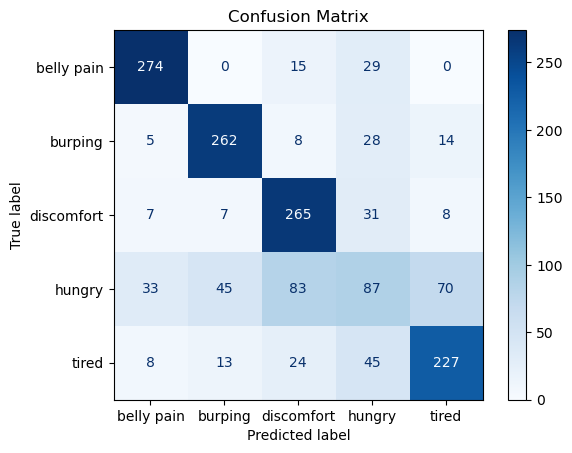

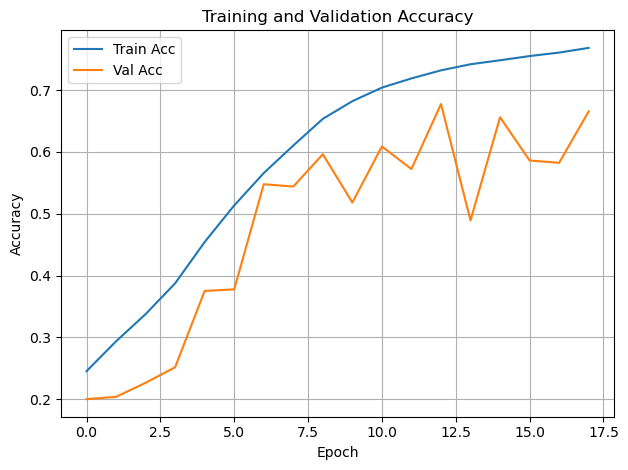

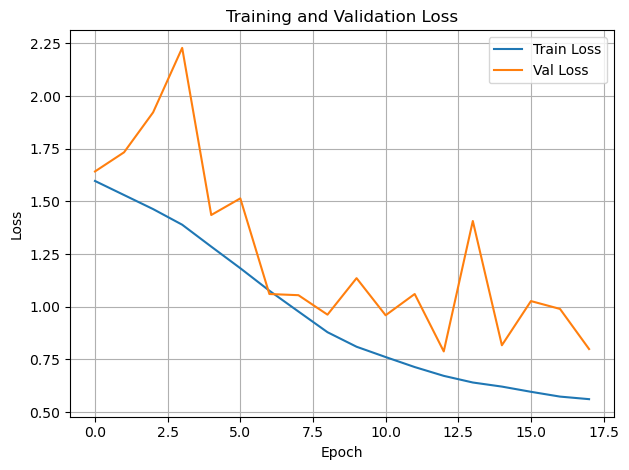

(0.7717254161834717, 0.6775818467140198, 0.7021410465240479)

In [2]:
print("\n==========================")
print("🔬 Running: ResLSTM | Adam | 0.001 | 60 Epochs | Split 80:10:10")
print("==========================")
run_attention_model(
    model_type="reslstm",
    optimizer_name="Adam", 
    lr=0.001,
    epochs=60,
    split_ratio=(0.8, 0.1, 0.1),
    batch_size=32
)



🔬 Running: ResLSTM | Adam | 0.001 | 60 Epochs | Split 70:15:15
Epoch 1/60
348/348 [==============================] - ETA: 0s - loss: 1.5904 - accuracy: 0.2473
Epoch 1: val_accuracy improved from -inf to 0.18472, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 348s 954ms/step - loss: 1.5904 - accuracy: 0.2473 - val_loss: 1.7584 - val_accuracy: 0.1847
Epoch 2/60
348/348 [==============================] - ETA: 0s - loss: 1.5379 - accuracy: 0.2921
Epoch 2: val_accuracy improved from 0.18472 to 0.23342, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 323s 927ms/step - loss: 1.5379 - accuracy: 0.2921 - val_loss: 1.7078 - val_accuracy: 0.2334
Epoch 3/60
348/348 [==============================] - ETA: 0s - loss: 1.4880 - accuracy: 0.3298
Epoch 3: val_accuracy improved from 0.23342 to 0.34173, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 320s 919ms/step - loss: 1.4880 - accuracy: 0.3298 - val_

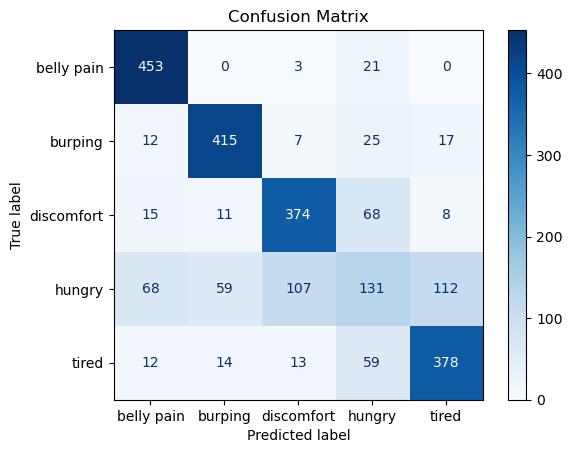

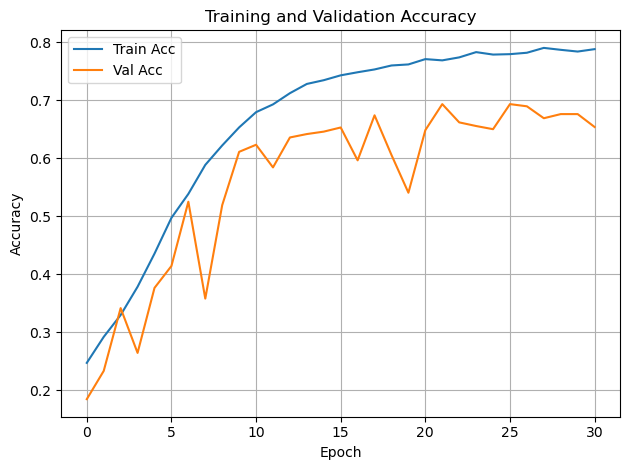

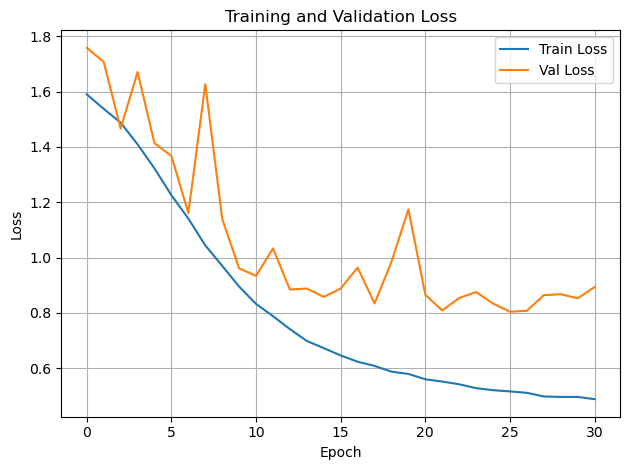

(0.8133321404457092, 0.6935348510742188, 0.7350965738296509)

In [3]:
print("\n==========================")
print("🔬 Running: ResLSTM | Adam | 0.001 | 60 Epochs | Split 70:15:15")
print("==========================")
run_attention_model(
    model_type="reslstm",
    optimizer_name="Adam", 
    lr=0.001,
    epochs=60,
    split_ratio=(0.7, 0.15, 0.15),
    batch_size=32
)



🔬 Running: ResLSTM | Adam | 0.001 | 60 Epochs | Split 70:20:10
Epoch 1/60
348/348 [==============================] - ETA: 0s - loss: 1.5856 - accuracy: 0.2321
Epoch 1: val_accuracy improved from -inf to 0.20050, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 363s 995ms/step - loss: 1.5856 - accuracy: 0.2321 - val_loss: 1.6506 - val_accuracy: 0.2005
Epoch 2/60
348/348 [==============================] - ETA: 0s - loss: 1.5165 - accuracy: 0.2988
Epoch 2: val_accuracy improved from 0.20050 to 0.30689, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 340s 977ms/step - loss: 1.5165 - accuracy: 0.2988 - val_loss: 1.5170 - val_accuracy: 0.3069
Epoch 3/60
348/348 [==============================] - ETA: 0s - loss: 1.4343 - accuracy: 0.3626
Epoch 3: val_accuracy did not improve from 0.30689
348/348 [==============================] - 353s 1s/step - loss: 1.4343 - accuracy: 0.3626 - val_loss: 1.5933 - val_accuracy: 0.2663
Epoch 4/60

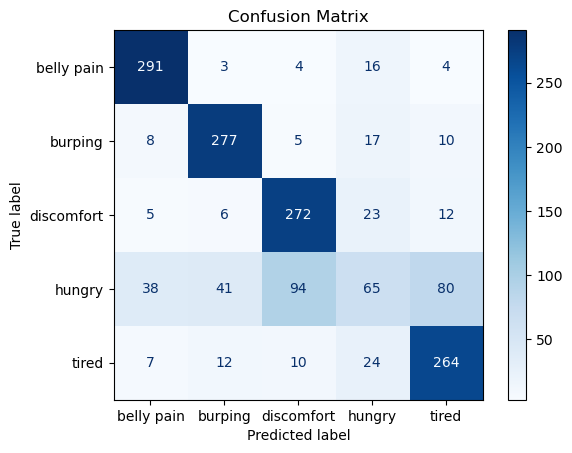

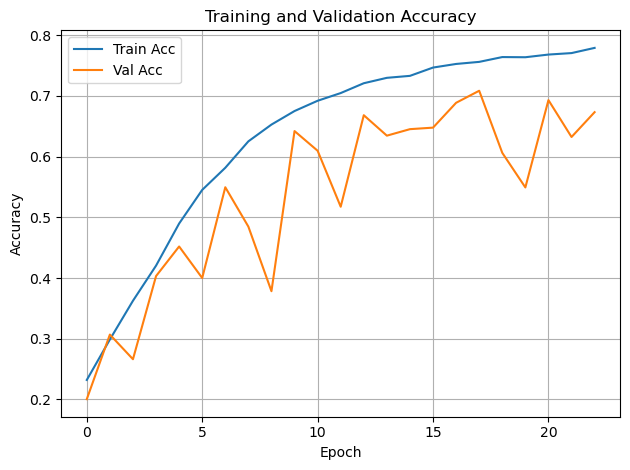

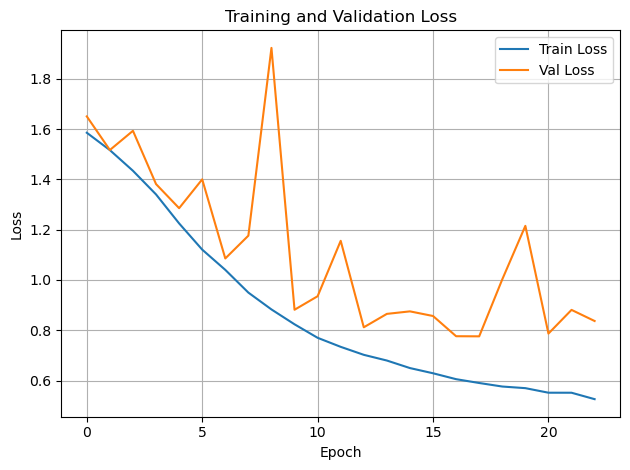

(0.7950517535209656, 0.708530068397522, 0.736146092414856)

In [4]:
print("\n==========================")
print("🔬 Running: ResLSTM | Adam | 0.001 | 60 Epochs | Split 70:20:10")
print("==========================")
run_attention_model(
    model_type="reslstm",
    optimizer_name="Adam", 
    lr=0.001,
    epochs=60,
    split_ratio=(0.7, 0.2, 0.1),
    batch_size=32
)



🔬 Running: ResLSTM | SGD | 0.01 | 60 Epochs | Split 70:20:10
Epoch 1/60
348/348 [==============================] - ETA: 0s - loss: 1.6172 - accuracy: 0.1978
Epoch 1: val_accuracy improved from -inf to 0.20271, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 362s 1s/step - loss: 1.6172 - accuracy: 0.1978 - val_loss: 1.6191 - val_accuracy: 0.2027
Epoch 2/60
348/348 [==============================] - ETA: 0s - loss: 1.6108 - accuracy: 0.2079
Epoch 2: val_accuracy improved from 0.20271 to 0.21530, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 336s 964ms/step - loss: 1.6108 - accuracy: 0.2079 - val_loss: 1.6131 - val_accuracy: 0.2153
Epoch 3/60
348/348 [==============================] - ETA: 0s - loss: 1.6086 - accuracy: 0.2174
Epoch 3: val_accuracy improved from 0.21530 to 0.21656, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 331s 952ms/step - loss: 1.6086 - accuracy: 0.2174 - val_loss:

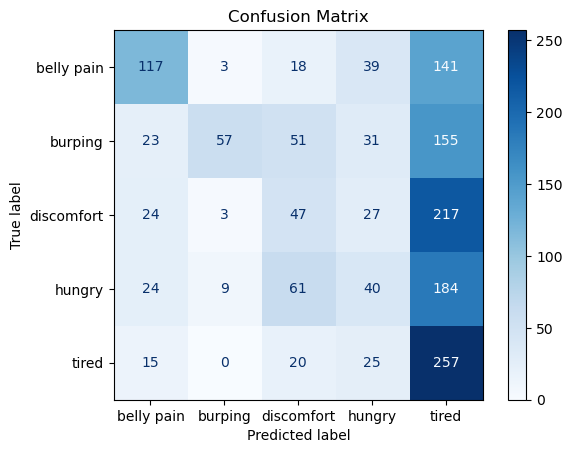

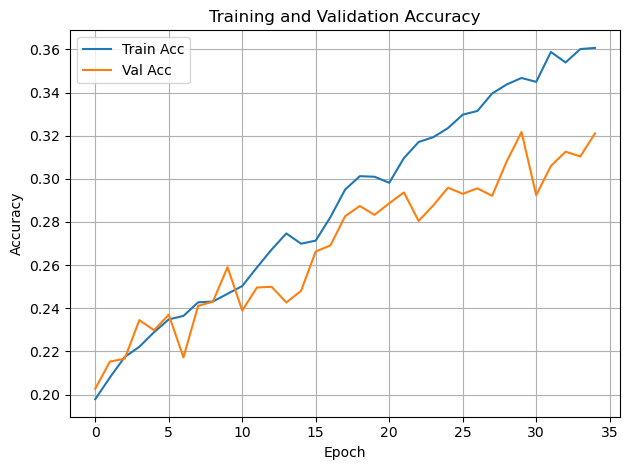

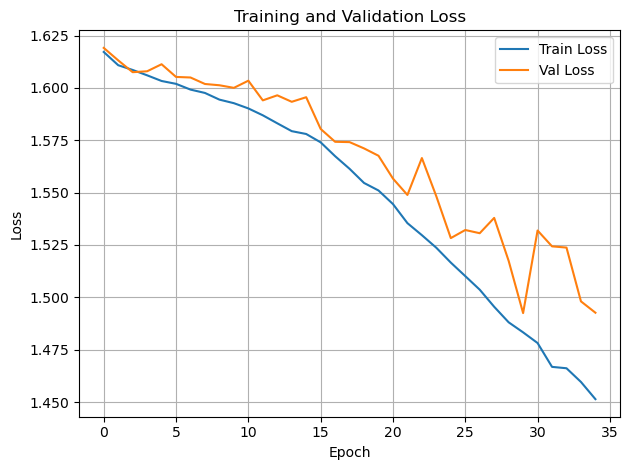

(0.3282051384449005, 0.32168713212013245, 0.32619646191596985)

In [5]:
print("\n==========================")
print("🔬 Running: ResLSTM | SGD | 0.01 | 60 Epochs | Split 70:20:10")
print("==========================")
run_attention_model(
    model_type="reslstm",
    optimizer_name="SGD", 
    lr=0.001,
    epochs=60,
    split_ratio=(0.7, 0.2, 0.1),
    batch_size=32
)



🔬 Running: ResLSTM | RMSprop | 0.01 | 60 Epochs | Split 70:20:10
Epoch 1/60
348/348 [==============================] - ETA: 0s - loss: 1.5784 - accuracy: 0.2512
Epoch 1: val_accuracy improved from -inf to 0.19862, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 473s 1s/step - loss: 1.5784 - accuracy: 0.2512 - val_loss: 1.6534 - val_accuracy: 0.1986
Epoch 2/60
348/348 [==============================] - ETA: 0s - loss: 1.4807 - accuracy: 0.3358
Epoch 2: val_accuracy improved from 0.19862 to 0.32326, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 448s 1s/step - loss: 1.4807 - accuracy: 0.3358 - val_loss: 1.5332 - val_accuracy: 0.3233
Epoch 3/60
348/348 [==============================] - ETA: 0s - loss: 1.3710 - accuracy: 0.4103
Epoch 3: val_accuracy did not improve from 0.32326
348/348 [==============================] - 448s 1s/step - loss: 1.3710 - accuracy: 0.4103 - val_loss: 1.5516 - val_accuracy: 0.2997
Epoch 4/60
348

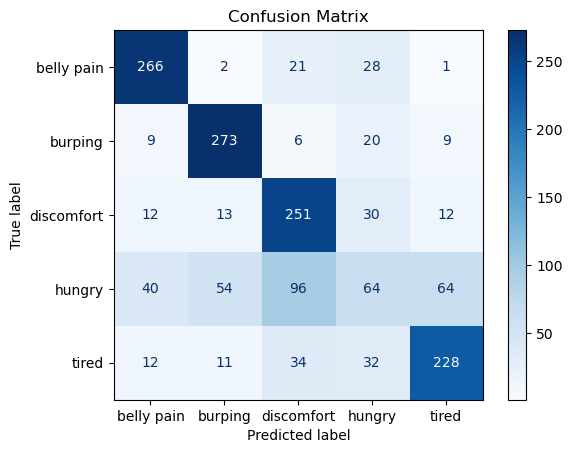

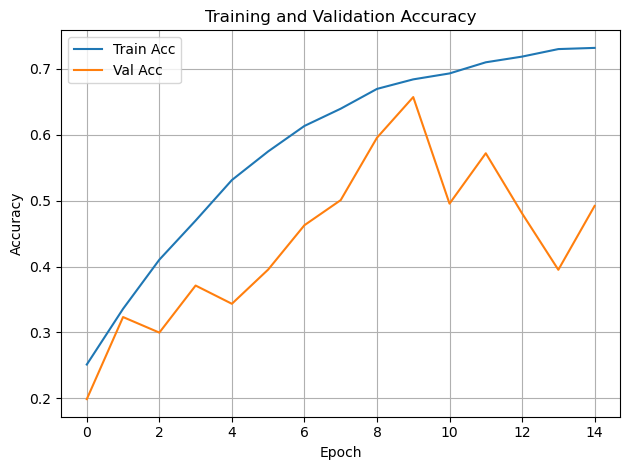

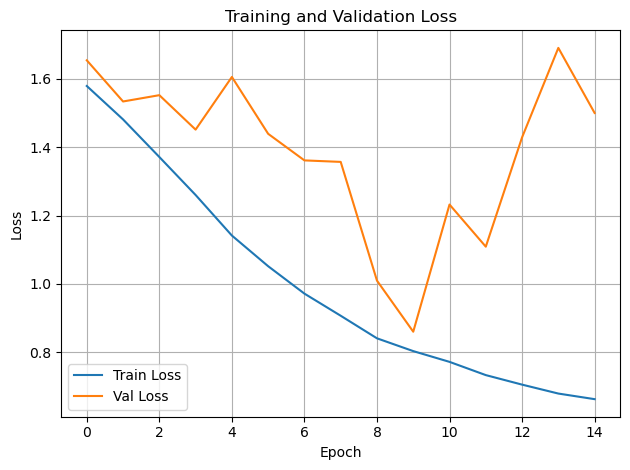

(0.7440395951271057, 0.6572238206863403, 0.6813601851463318)

In [6]:
print("\n==========================")
print("🔬 Running: ResLSTM | RMSprop | 0.001 | 60 Epochs | Split 70:20:10")
print("==========================")
run_attention_model(
    model_type="reslstm",
    optimizer_name="RMSprop", 
    lr=0.001,
    epochs=60,
    split_ratio=(0.7, 0.2, 0.1),
    batch_size=32
)


🔬 Running: ResLSTM | Adam | 0.0005 | 60 Epochs | Split 70:20:10
Epoch 1/60
348/348 [==============================] - ETA: 0s - loss: 1.5645 - accuracy: 0.2582
Epoch 1: val_accuracy improved from -inf to 0.20019, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 484s 1s/step - loss: 1.5645 - accuracy: 0.2582 - val_loss: 1.7071 - val_accuracy: 0.2002
Epoch 2/60
348/348 [==============================] - ETA: 0s - loss: 1.4882 - accuracy: 0.3271
Epoch 2: val_accuracy improved from 0.20019 to 0.33868, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 459s 1s/step - loss: 1.4882 - accuracy: 0.3271 - val_loss: 1.4744 - val_accuracy: 0.3387
Epoch 3/60
348/348 [==============================] - ETA: 0s - loss: 1.4049 - accuracy: 0.3865
Epoch 3: val_accuracy improved from 0.33868 to 0.38590, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 451s 1s/step - loss: 1.4049 - accuracy: 0.3865 - val_loss: 1.

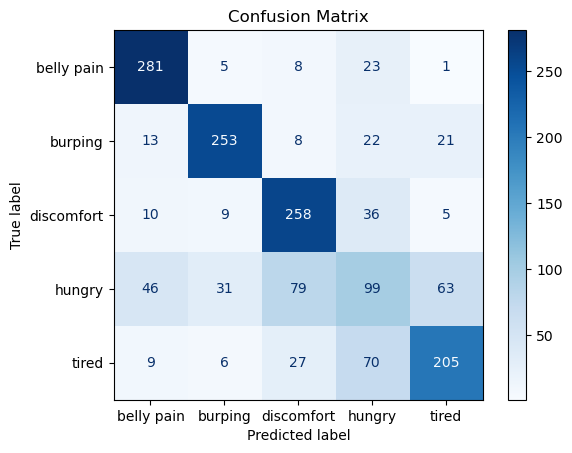

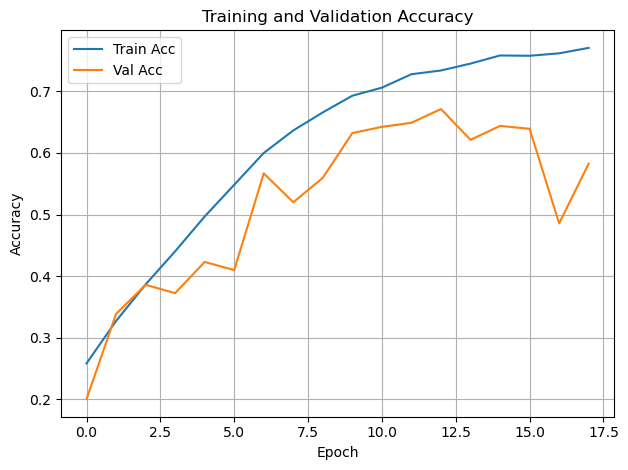

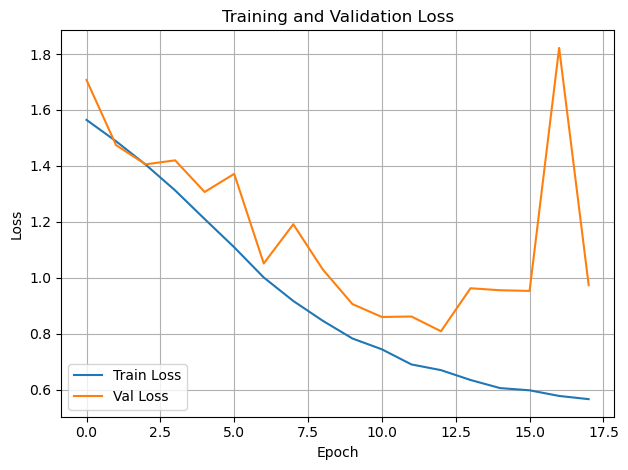

(0.758704423904419, 0.6713880896568298, 0.6901763081550598)

In [7]:
print("\n==========================")
print("🔬 Running: ResLSTM | Adam | 0.0005 | 60 Epochs | Split 70:20:10")
print("==========================")
run_attention_model(
    model_type="reslstm",
    optimizer_name="Adam", 
    lr=0.0005,
    epochs=60,
    split_ratio=(0.7, 0.2, 0.1),
    batch_size=32
)


🔬 Running: ResLSTM | Adam | 0.0001 | 60 Epochs | Split 70:20:10
Epoch 1/60
348/348 [==============================] - ETA: 0s - loss: 1.5982 - accuracy: 0.2356
Epoch 1: val_accuracy improved from -inf to 0.19452, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 368s 1s/step - loss: 1.5982 - accuracy: 0.2356 - val_loss: 1.7930 - val_accuracy: 0.1945
Epoch 2/60
348/348 [==============================] - ETA: 0s - loss: 1.5465 - accuracy: 0.3019
Epoch 2: val_accuracy improved from 0.19452 to 0.28455, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 340s 977ms/step - loss: 1.5465 - accuracy: 0.3019 - val_loss: 1.5562 - val_accuracy: 0.2845
Epoch 3/60
348/348 [==============================] - ETA: 0s - loss: 1.4812 - accuracy: 0.3492
Epoch 3: val_accuracy improved from 0.28455 to 0.34341, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 343s 987ms/step - loss: 1.4812 - accuracy: 0.3492 - val_lo

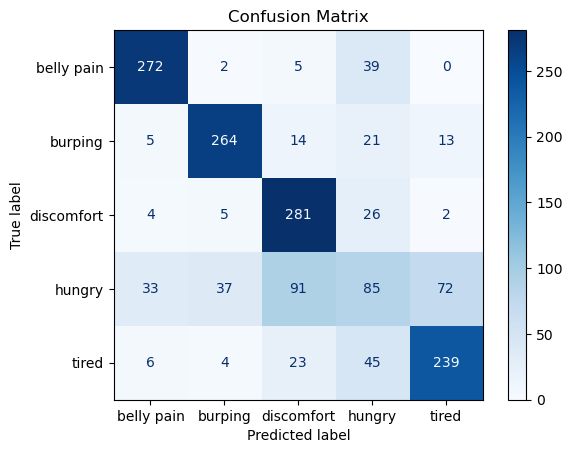

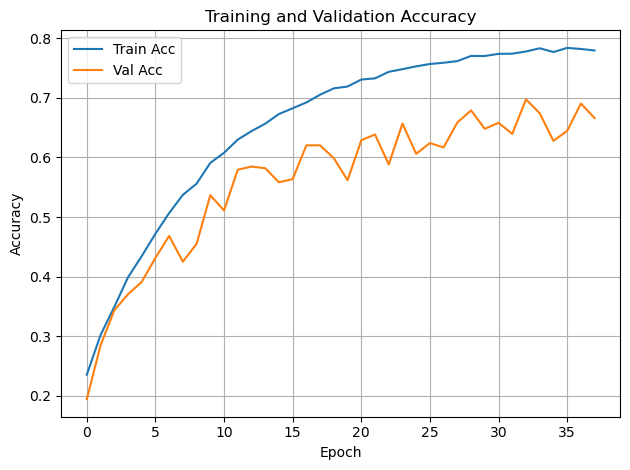

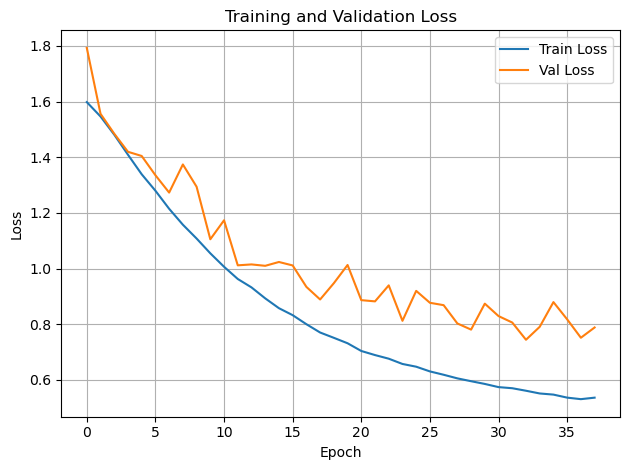

(0.8026090860366821, 0.6975134015083313, 0.7185138463973999)

In [8]:
print("\n==========================")
print("🔬 Running: ResLSTM | Adam | 0.0001 | 60 Epochs | Split 70:20:10")
print("==========================")
run_attention_model(
    model_type="reslstm",
    optimizer_name="Adam", 
    lr=0.0001,
    epochs=60,
    split_ratio=(0.7, 0.2, 0.1),
    batch_size=32
)


🔬 Running: ResLSTM | Adam | 0.001 | 40 Epochs | Split 70:20:10
Epoch 1/40
348/348 [==============================] - ETA: 0s - loss: 1.5813 - accuracy: 0.2408
Epoch 1: val_accuracy improved from -inf to 0.20019, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 479s 1s/step - loss: 1.5813 - accuracy: 0.2408 - val_loss: 1.6872 - val_accuracy: 0.2002
Epoch 2/40
348/348 [==============================] - ETA: 0s - loss: 1.5260 - accuracy: 0.2935
Epoch 2: val_accuracy improved from 0.20019 to 0.31004, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 449s 1s/step - loss: 1.5260 - accuracy: 0.2935 - val_loss: 1.5090 - val_accuracy: 0.3100
Epoch 3/40
348/348 [==============================] - ETA: 0s - loss: 1.4759 - accuracy: 0.3365
Epoch 3: val_accuracy improved from 0.31004 to 0.37394, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 450s 1s/step - loss: 1.4759 - accuracy: 0.3365 - val_loss: 1.4

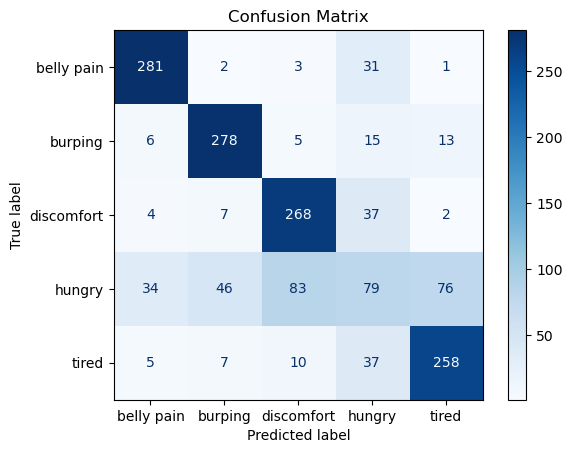

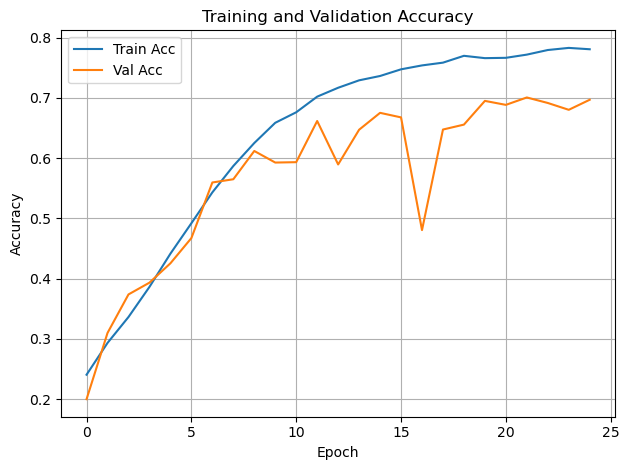

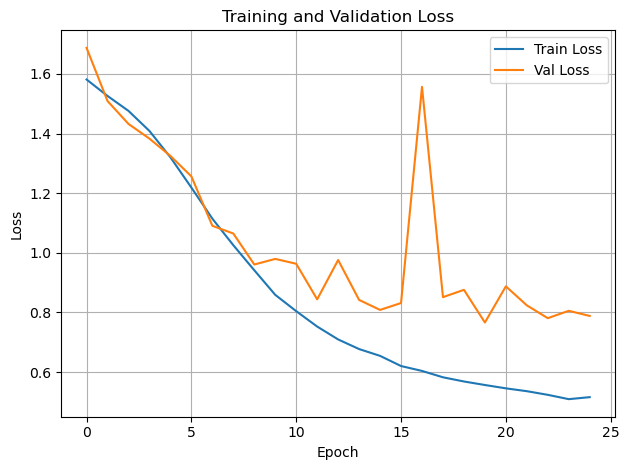

(0.8018893599510193, 0.6949952840805054, 0.732997477054596)

In [9]:
print("\n==========================")
print("🔬 Running: ResLSTM | Adam | 0.001 | 40 Epochs | Split 70:20:10")
print("==========================")
run_attention_model(
    model_type="reslstm",
    optimizer_name="Adam", 
    lr=0.001,
    epochs=40,
    split_ratio=(0.7, 0.2, 0.1),
    batch_size=32
)


🔬 Running: ResLSTM | Adam | 0.001 | 20 Epochs | Split 70:20:10
Epoch 1/20
348/348 [==============================] - ETA: 0s - loss: 1.6009 - accuracy: 0.2381
Epoch 1: val_accuracy improved from -inf to 0.19043, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 363s 997ms/step - loss: 1.6009 - accuracy: 0.2381 - val_loss: 1.7154 - val_accuracy: 0.1904
Epoch 2/20
348/348 [==============================] - ETA: 0s - loss: 1.5625 - accuracy: 0.2873
Epoch 2: val_accuracy improved from 0.19043 to 0.24300, saving model to best_model_ResLSTM.h5
348/348 [==============================] - 341s 979ms/step - loss: 1.5625 - accuracy: 0.2873 - val_loss: 1.6972 - val_accuracy: 0.2430
Epoch 3/20
348/348 [==============================] - ETA: 0s - loss: 1.5098 - accuracy: 0.3262
Epoch 3: val_accuracy did not improve from 0.24300
348/348 [==============================] - 336s 967ms/step - loss: 1.5098 - accuracy: 0.3262 - val_loss: 1.9754 - val_accuracy: 0.2140
Epoch 4

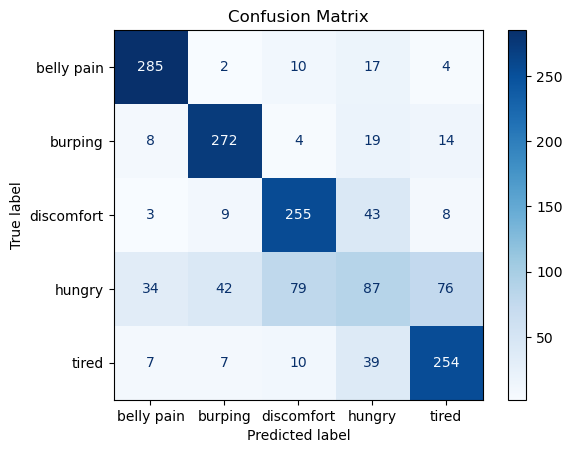

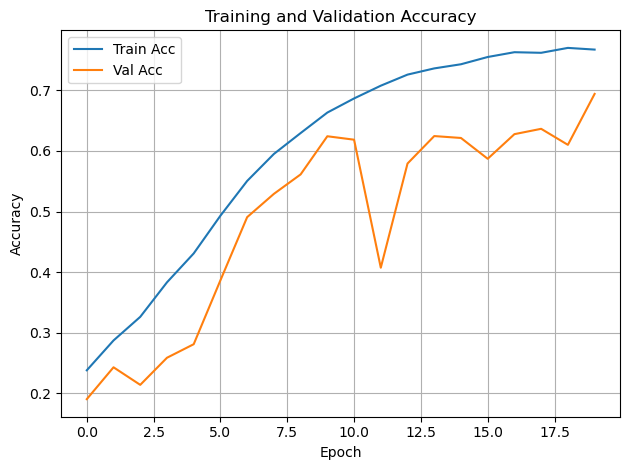

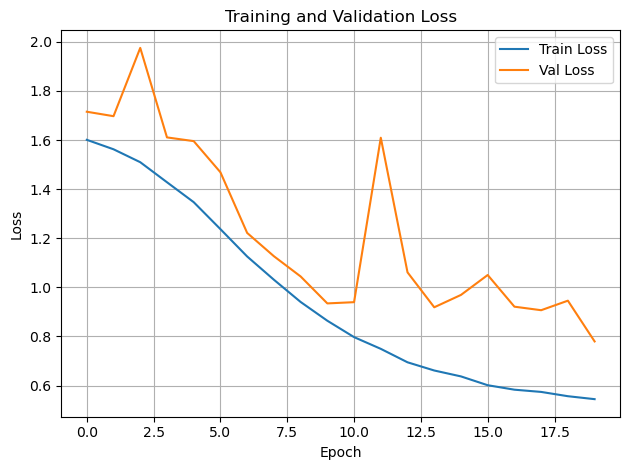

(0.8051282167434692, 0.6940509676933289, 0.7260705232620239)

In [10]:
print("\n==========================")
print("🔬 Running: ResLSTM | Adam | 0.001 | 20 Epochs | Split 70:20:10")
print("==========================")
run_attention_model(
    model_type="reslstm",
    optimizer_name="Adam", 
    lr=0.001,
    epochs=20,
    split_ratio=(0.7, 0.2, 0.1),
    batch_size=32
)

In [ ]:

from copy import deepcopy
import os
import pandas as pd
import json

best_val_acc = 0.0
best_model_state = None
best_optimizer_name = ""
results_list = []


In [ ]:
# Insert this block inside your training loop after validation

# === Check and Save Best Model ===
if val_acc > best_val_acc:
    best_val_acc = val_acc
    best_model_state = deepcopy(model.state_dict())
    best_optimizer_name = optimizer_name

# === Store results for comparison ===
results_list.append({
    "model": "ResLSTM",
    "optimizer": optimizer_name,
    "learning_rate": lr,
    "epochs": epochs,
    "train_accuracy": train_acc,
    "val_accuracy": val_acc,
    "precision": precision,
    "recall": recall,
    "f1_score": f1
})
